# GLIPH-like Multi-family Enrichment and Full-Graph Clustering (TRB)

This notebook implements a GLIPH-style workflow on TRB clonotypes with expanded token families and a full graph stage:

1. Load `gliph_trb.tsv.gz` from the local benchmark cache.
2. Collapse each study to a unique list of `(v_gene, junction_aa)` clonotypes before token counting.
3. Build five token families per clonotype:
   - **v+3-mer**
   - **pos+3mer**
   - **ungapped 4-mer**
   - **gapped 4-mer**
   - **gapped 5-mer**
4. Compare sample-vs-control **VJ usage** after V-only control normalization to diagnose residual gene-usage drift.
5. For each study and family, run **binomial enrichment** against a V-only matched real TRB control sample of size `1,000,000`.
6. Plot separate volcano plots for each family/study pair, showing only the `enrichment ratio > 1.0` side.
7. Merge all enriched tokens into a heterogeneous graph (token-clonotype edges + clonotype-clonotype Hamming `<= 1` edges).
8. Expand the clonotype set by one Hamming-hop from the current graph.
9. Build one-mode projections (clonotype and k-mer sides), run connected components and Leiden communities, and evaluate concordance against `stimulus` and `gliph_cluster_id`.

The implementation reuses `mir/**` components for token extraction, control normalization, binomial enrichment, and edit-distance graph construction.

In [1]:
from __future__ import annotations

from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path
import importlib
import re
import time

import igraph as ig
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import Markdown, display
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

import mir.graph.token_graph as token_graph_mod
import mir.biomarkers.gliph as gliph_mod
importlib.reload(token_graph_mod)
importlib.reload(gliph_mod)

from mir.biomarkers.gliph import (
    GliphTokenArtifacts,
    build_full_gliph_clonotype_graph,
    build_kmer_projection_graph,
    combine_enriched_token_maps,
    compare_gliph_token_incidence,
    extract_gliph_artifacts_batch_from_repertoire,
)
from mir.basic.gene_usage import GeneUsage
from mir.common.repertoire import LocusRepertoire
from mir.utils.notebook_assets import ensure_airr_benchmark, find_repo_root


/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configuration: analysis parameters and runtime caps

import re
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Markdown

repo_root = find_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

SEED = 42
np.random.seed(SEED)

STUDY_KEYWORDS = {
    'Glanville2017': 'glanville',
    'Huang2020': 'huang',
}

FAMILIES = ['v3', 'pos3', 'u3', 'u4', 'g4', 'g5']
TOKEN_THREADS = 8
COUNT_MODE = 'clonotype'
MIN_TOKEN_CLONOTYPES = 2
KMER_PSEUDOCOUNT = 1
SIG_FDR = 0.05
SIG_ENRICHMENT = 1.0
SIG_ODDS = 1.5
MIN_CLUSTER_SIZE = 2
CLONE_EDGE_MIN_WEIGHT = 0.35
MAX_GRAPH_NODES = 800
TOP_LABELS = 5

# Unnormalized control background size used for token extraction.
# This keeps runtime predictable while preserving native control composition.
CONTROL_BACKGROUND_N = 1_000_000

FAMILY_LABELS = {
    'v3': 'V3', 'pos3': 'Pos3', 'u3': 'U3', 'u4': 'U4', 'g4': 'G4', 'g5': 'G5'
}
FAMILY_COLORS = {
    'v3': '#FF6B6B', 'pos3': '#4ECDC4', 'u3': '#577590', 'u4': '#45B7D1',
    'g4': '#FFA07A', 'g5': '#98D8C8'
}
STIMULUS_PALETTE = {
    'HIV': '#e74c3c', 'SIV': '#3498db', 'CMV': '#f39c12',
    'CEF': '#27ae60', 'EBV': '#9b59b6', 'Flu': '#1abc9c',
}

CLUSTER_METHODS = ['components', 'leiden']
AA_RE = re.compile(r'^[A-Z]+$')

REPO_GLPH_PATH = repo_root / 'airr_benchmark' / 'gliph' / 'gliph_trb.tsv.gz'
NOTEBOOK_GLPH_PATH = repo_root / 'notebooks' / 'assets' / 'large' / 'airr_benchmark' / 'gliph' / 'gliph_trb.tsv.gz'
HF_PATTERN = ['gliph/gliph_trb.tsv.gz']
FORCE_HF_REFRESH = False
CONTROL_LOCUS = 'TRB'


In [3]:
# Helper functions for GLIPH data processing

def _resolve_gliph_path(force_hf_refresh: bool = FORCE_HF_REFRESH) -> Path:
    """Resolve path to gliph_trb.tsv.gz dataset."""
    if REPO_GLPH_PATH.exists() and not force_hf_refresh:
        return REPO_GLPH_PATH
    if NOTEBOOK_GLPH_PATH.exists() and not force_hf_refresh:
        return NOTEBOOK_GLPH_PATH
    ds_root = ensure_airr_benchmark(repo_root=repo_root, allow_patterns=HF_PATTERN)
    path = ds_root / 'gliph' / 'gliph_trb.tsv.gz'
    if not path.exists():
        raise FileNotFoundError(f'Could not find gliph_trb.tsv.gz at {path}')
    return path


def _repertoire_summary(repertoire: LocusRepertoire) -> dict[str, int]:
    """Get summary statistics for a repertoire."""
    clones = repertoire.clonotypes
    return {
        'clonotypes': len(clones),
        'total_duplicates': sum(c.duplicate_count for c in clones),
        'with_aa': sum(1 for c in clones if c.junction_aa and len(c.junction_aa) >= 5),
    }


In [4]:
# Load GLIPH table and build per-study repertoires

gliph_path = _resolve_gliph_path()
print(f'Loading GLIPH data from {gliph_path}')

raw_df = pd.read_csv(gliph_path, sep='\t', compression='infer', low_memory=False)

df = pd.DataFrame({
    'sequence_id': raw_df.index.astype(str),
    'junction_aa': raw_df['junction_aa'].astype(str).str.strip(),
    'v_gene': raw_df['v_gene'].astype(str).str.strip(),
    'j_gene': raw_df.get('j_gene', '').astype(str).str.strip() if 'j_gene' in raw_df.columns else '',
    'duplicate_count': pd.to_numeric(raw_df.get('duplicate_count', 1), errors='coerce').fillna(1).astype(int),
    'reference_id': raw_df['reference_id'].astype(str).str.strip(),
    'stimulus': raw_df.get('stimulus', '').astype(str).str.strip() if 'stimulus' in raw_df.columns else '',
    'epitope': raw_df.get('epitope', '').astype(str).str.strip() if 'epitope' in raw_df.columns else '',
    'gliph_cluster_id': raw_df.get('gliph_cluster_id', '').astype(str).str.strip() if 'gliph_cluster_id' in raw_df.columns else '',
})

# Keep only valid amino-acid clonotypes
df = df[(df['junction_aa'].str.len() >= 5) & (df['junction_aa'].str.match(AA_RE))].copy()

# Deduplicate once for token incidence model
df_dedup = df.groupby(['reference_id', 'junction_aa', 'v_gene'], as_index=False, sort=False).agg({
    'duplicate_count': 'sum',
    'j_gene': 'first',
    'stimulus': 'first',
    'epitope': 'first',
    'gliph_cluster_id': 'first',
}).reset_index(drop=True)
df_dedup['sequence_id'] = df_dedup.index.astype(str)
df_dedup['row_id'] = df_dedup['sequence_id']

# Build repertoires per study for extraction
study_repertoires = {}
for study, sdf in df_dedup.groupby('reference_id', sort=True):
    pl_df = pl.from_pandas(
        sdf[['sequence_id', 'junction_aa', 'v_gene', 'j_gene', 'duplicate_count']],
        include_index=False,
    )
    study_repertoires[str(study)] = LocusRepertoire.from_polars(
        pl_df,
        locus=CONTROL_LOCUS,
        repertoire_id=str(study),
    )

print(f'Loaded {len(raw_df):,} raw clonotypes')
print(f'After filtering: {len(df):,}')
print(f'Deduplicated clonotypes: {len(df_dedup):,}')
print('Per-study repertoire sizes:')
for study, rep in study_repertoires.items():
    print(f'  {study}: {rep.clonotype_count:,}')

display(df_dedup.groupby('reference_id').size().to_frame('clonotypes'))
display(df_dedup.head(3))


Loading GLIPH data from /Users/mikesh/vcs/mirpy/airr_benchmark/gliph/gliph_trb.tsv.gz
Loaded 17,936 raw clonotypes
After filtering: 17,936
Deduplicated clonotypes: 13,864
Per-study repertoire sizes:
  Glanville2017: 3,930
  Huang2020: 9,934


,clonotypes
reference_id,
Glanville2017,3930
Huang2020,9934


,reference_id,junction_aa,v_gene,duplicate_count,j_gene,stimulus,epitope,gliph_cluster_id,sequence_id,row_id
0,Glanville2017,CASSPNGIMNTEAFF,TRBV7-6,50835,TRBJ1-1,MegaIL2,NaN,C3282,0,0
1,Glanville2017,CASTQSGGTNEKLFF,TRBV28,110298,TRBJ1-4,MegaIL2,NaN,C3374,1,1
2,Glanville2017,CASSAWDRGRFTEAFF,TRBV25-1,91536,TRBJ1-1,MegaIL2,NaN,C626,2,2


In [5]:
# Build control repertoire once and extract all families once

from mir.common.control import ControlManager

ctrl_manager = ControlManager()
print('Loading real human TRB control repertoire...')
t0 = time.perf_counter()
ctrl_raw = ctrl_manager.ensure_and_load_control_df('real', 'human', CONTROL_LOCUS)
print(f'Loaded {len(ctrl_raw):,} control rows in {time.perf_counter() - t0:.1f}s')

# Convert full control to repertoire object
ctrl_pl = pl.from_pandas(
    pd.DataFrame({
        'sequence_id': np.arange(len(ctrl_raw)).astype(str),
        'junction_aa': ctrl_raw['junction_aa'].astype(str).str.strip(),
        'v_gene': ctrl_raw['v_gene'].astype(str).str.strip(),
        'j_gene': ctrl_raw.get('j_gene', '').astype(str).str.strip() if 'j_gene' in ctrl_raw.columns else '',
        'duplicate_count': pd.to_numeric(ctrl_raw.get('duplicate_count', 1), errors='coerce').fillna(1).astype(int),
    }),
    include_index=False,
).filter((pl.col('junction_aa').str.len_chars() >= 5))

control_repertoire_full = LocusRepertoire.from_polars(
    ctrl_pl,
    locus=CONTROL_LOCUS,
    repertoire_id='real_human_trb_full',
)

# Unnormalized random sample from control repertoire to keep extraction bounded
rng = np.random.default_rng(SEED)
control_clones_all = control_repertoire_full.clonotypes
n_bg = min(CONTROL_BACKGROUND_N, len(control_clones_all))
bg_idx = rng.choice(len(control_clones_all), size=n_bg, replace=False)
control_repertoire = LocusRepertoire(
    [control_clones_all[i] for i in bg_idx],
    locus=CONTROL_LOCUS,
    repertoire_id=f'real_human_trb_bg_{n_bg}',
)

print(f'Using control background size: {control_repertoire.clonotype_count:,} (unnormalized sample)')

# Compute control artifacts once for all families
t0 = time.perf_counter()
ctrl_artifacts = extract_gliph_artifacts_batch_from_repertoire(
    control_repertoire,
    FAMILIES,
    count_mode=COUNT_MODE,
)
print(f'Control token extraction finished in {time.perf_counter() - t0:.1f}s')
for family in FAMILIES:
    print(f'  {family}: {len(ctrl_artifacts[family].counts):,} tokens')


Loading real human TRB control repertoire...
Loaded 28,257,621 control rows in 26.7s
Using control background size: 1,000,000 (unnormalized sample)
Control token extraction finished in 520.7s
  v3: 215,583 tokens
  pos3: 760,410 tokens
  u3: 7,692 tokens
  u4: 102,198 tokens
  g4: 30,468 tokens
  g5: 487,083 tokens


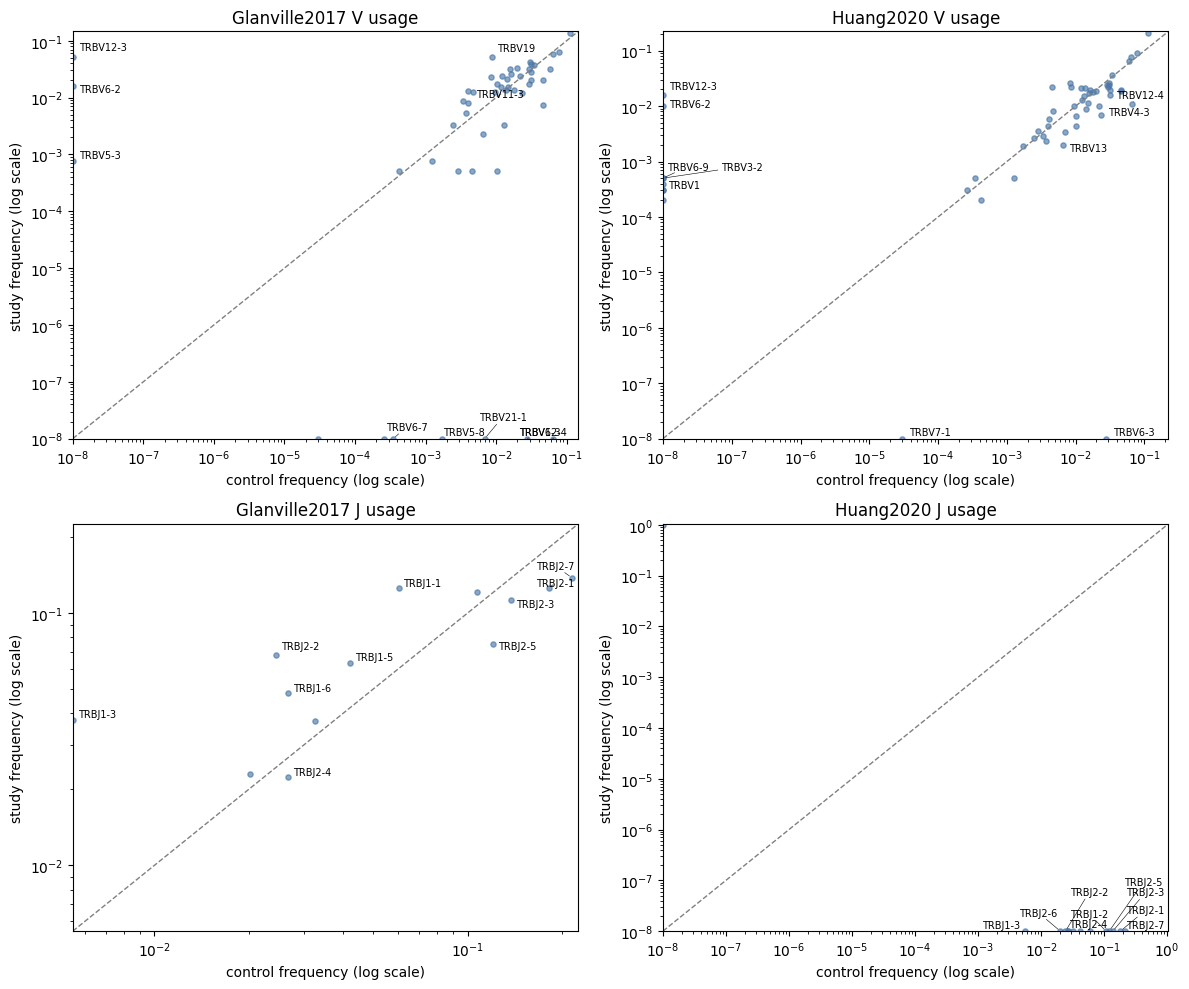

In [ ]:
# Compare marginal V/J usage (study vs shared control background) on log-log axes
# N.B. Huang2020 does not report J genes
from adjustText import adjust_text
import contextlib
import io

def _usage_frame(usage: dict[str, int], label: str) -> pd.DataFrame:
    return pd.DataFrame({'gene': list(usage.keys()), label: list(usage.values())})

def _plot_usage_scatter(ax, merged: pd.DataFrame, x_col: str, y_col: str, title: str):
    if merged.empty:
        ax.set_title(f'{title} (no overlap)')
        ax.axis('off')
        return

    merged = merged.copy()
    merged[x_col] = merged[x_col].astype(float)
    merged[y_col] = merged[y_col].astype(float)
    eps = 1e-8
    merged['x_plot'] = merged[x_col] + eps
    merged['y_plot'] = merged[y_col] + eps
    merged['log2_fc'] = np.log2(merged['y_plot'] / merged['x_plot'])

    ax.scatter(merged['x_plot'], merged['y_plot'], s=14, alpha=0.65, color='#4c78a8')
    min_lim = min(float(merged['x_plot'].min()), float(merged['y_plot'].min()))
    max_lim = max(float(merged['x_plot'].max()), float(merged['y_plot'].max())) * 1.05
    ax.plot([min_lim, max_lim], [min_lim, max_lim], '--', color='gray', linewidth=1.0)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(min_lim, max_lim)
    ax.set_ylim(min_lim, max_lim)
    ax.set_xlabel('control frequency (log scale)')
    ax.set_ylabel('study frequency (log scale)')
    ax.set_title(title)

    top_over = merged.nlargest(5, 'log2_fc')
    top_under = merged.nsmallest(5, 'log2_fc')
    label_df = pd.concat([top_over, top_under], axis=0).drop_duplicates('gene')

    texts = []
    for _, row in label_df.iterrows():
        texts.append(ax.text(row['x_plot'], row['y_plot'], str(row['gene']), fontsize=7))
    if texts:
        with contextlib.redirect_stdout(io.StringIO()):
            adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='black', lw=0.4))


control_usage = GeneUsage.from_repertoire(control_repertoire)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

for col_i, study in enumerate(sorted(study_repertoires.keys())):
    study_usage = GeneUsage.from_repertoire(study_repertoires[study])

    ctrl_v = control_usage.v_fraction(CONTROL_LOCUS, count='clonotypes', pseudocount=1.0)
    std_v = study_usage.v_fraction(CONTROL_LOCUS, count='clonotypes', pseudocount=1.0)
    v_df = _usage_frame(ctrl_v, 'control').merge(_usage_frame(std_v, 'study'), on='gene', how='outer').fillna(0.0)
    _plot_usage_scatter(axes[0, col_i], v_df, 'control', 'study', f'{study} V usage')

    ctrl_j = control_usage.j_fraction(CONTROL_LOCUS, count='clonotypes', pseudocount=1.0)
    std_j = study_usage.j_fraction(CONTROL_LOCUS, count='clonotypes', pseudocount=1.0)
    j_df = _usage_frame(ctrl_j, 'control').merge(_usage_frame(std_j, 'study'), on='gene', how='outer').fillna(0.0)
    _plot_usage_scatter(axes[1, col_i], j_df, 'control', 'study', f'{study} J usage')

plt.tight_layout()
plt.show()


## Tokenization and Binomial Enrichment

Each token family is tested separately with a binomial enrichment model:

- Sample clonotypes are deduplicated first to unique `(reference_id, v_gene, junction_aa)` rows.
- Controls are resampled to match **V usage only**.
- For each token, we test sample support (`count_1 / total_sample_clonotypes`) against `p_background = count_2 / total_control_clonotypes`.
- The enrichment cutoff for downstream graph construction is `FDR < 0.05`, `enrichment_ratio > 1.0`, and at least `2` supporting clonotypes.

In [6]:
# Enrichment helper functions

def _run_enrichment(
    sample_art: GliphTokenArtifacts,
    ctrl_art: GliphTokenArtifacts,
) -> pd.DataFrame:
    return compare_gliph_token_incidence(
        sample_art,
        ctrl_art,
        test='binom',
        p_adj_method='fdr_bh',
        pseudocount=KMER_PSEUDOCOUNT,
    )


def _significant_tokens(comp: pd.DataFrame, sample_art: GliphTokenArtifacts) -> tuple[pd.DataFrame, pd.Series]:
    support = pd.Series(sample_art.clonotype_counts, name='sample_clonotypes')
    comp = comp.join(support, how='left').fillna({'sample_clonotypes': 0})
    comp['sample_clonotypes'] = comp['sample_clonotypes'].astype(int)
    sig_mask = (
        (comp['p_val_adj'] < SIG_FDR)
        & (comp['freq_fc'] > SIG_ODDS)
        & (comp['sample_clonotypes'] >= MIN_TOKEN_CLONOTYPES)
    )
    return comp, sig_mask


def _family_from_token(token: str) -> str:
    return token.split('::', 1)[0]


def _token_display_name(token: str) -> str:
    parts = token.split('::')
    family = parts[0]
    if family == 'v3':
        return f"{parts[1]}:{parts[2]}"
    if family == 'pos3':
        return f"{parts[1]}@{parts[2]}:{parts[3]}"
    return parts[1]


In [7]:
# Run per-study enrichment with shared control background

study_results: dict[str, dict] = {fam: {} for fam in FAMILIES}
enrichment_overview_rows: list[dict[str, object]] = []

for study, study_rep in study_repertoires.items():
    sdf = df_dedup[df_dedup['reference_id'] == study].copy()
    print(f'\n=== {study} ===')

    t0 = time.perf_counter()
    sample_batch = extract_gliph_artifacts_batch_from_repertoire(
        study_rep,
        FAMILIES,
        count_mode=COUNT_MODE,
    )
    print(f'  Sample token extraction (all families): {time.perf_counter() - t0:.1f}s')

    for family in FAMILIES:
        sample_art = sample_batch[family]
        ctrl_art = ctrl_artifacts[family]

        comp = _run_enrichment(sample_art, ctrl_art)
        comp, sig_mask = _significant_tokens(comp, sample_art)
        enriched_tokens = set(comp.index[sig_mask])

        study_results[family][study] = {
            'study_art': sample_art,
            'ctrl_art': ctrl_art,
            'comparison': comp,
            'sig_mask': sig_mask,
            'enriched_tokens': enriched_tokens,
            'study_df': sdf,
        }

        enrichment_overview_rows.append({
            'reference_id': study,
            'family': family,
            'token_family': FAMILY_LABELS[family],
            'n_tokens_total': len(comp),
            'n_tokens_sig': int(sig_mask.sum()),
            'median_sample_clonotypes': float(comp['sample_clonotypes'].median()),
        })
        print(f'  {family}: {int(sig_mask.sum())} enriched / {len(comp)} total')

enrichment_overview = pd.DataFrame(enrichment_overview_rows).sort_values(
    ['reference_id', 'family']
).reset_index(drop=True)
display(enrichment_overview)



=== Glanville2017 ===
  Sample token extraction (all families): 0.5s
  v3: 253 enriched / 216782 total
  pos3: 18 enriched / 763136 total
  u3: 5 enriched / 7698 total
  u4: 0 enriched / 102283 total
  g4: 7 enriched / 30492 total
  g5: 0 enriched / 487482 total

=== Huang2020 ===
  Sample token extraction (all families): 0.9s
  v3: 395 enriched / 217287 total
  pos3: 206 enriched / 765298 total
  u3: 122 enriched / 7704 total
  u4: 47 enriched / 102554 total
  g4: 426 enriched / 30512 total
  g5: 246 enriched / 488724 total


,reference_id,family,token_family,n_tokens_total,n_tokens_sig,median_sample_clonotypes
0,Glanville2017,g4,G4,30492,7,0.0
1,Glanville2017,g5,G5,487482,0,0.0
2,Glanville2017,pos3,Pos3,763136,18,0.0
3,Glanville2017,u3,U3,7698,5,0.0
4,Glanville2017,u4,U4,102283,0,0.0
5,Glanville2017,v3,V3,216782,253,0.0
6,Huang2020,g4,G4,30512,426,1.0
7,Huang2020,g5,G5,488724,246,0.0
8,Huang2020,pos3,Pos3,765298,206,0.0
9,Huang2020,u3,U3,7704,122,1.0


## Separate Volcano Plots by Family and Study

Each panel shows one family/study binomial comparison. Tokens passing `FDR < 0.05`, `enrichment_ratio > 1.0`, and `sample_clonotypes >= 2` are highlighted in red.

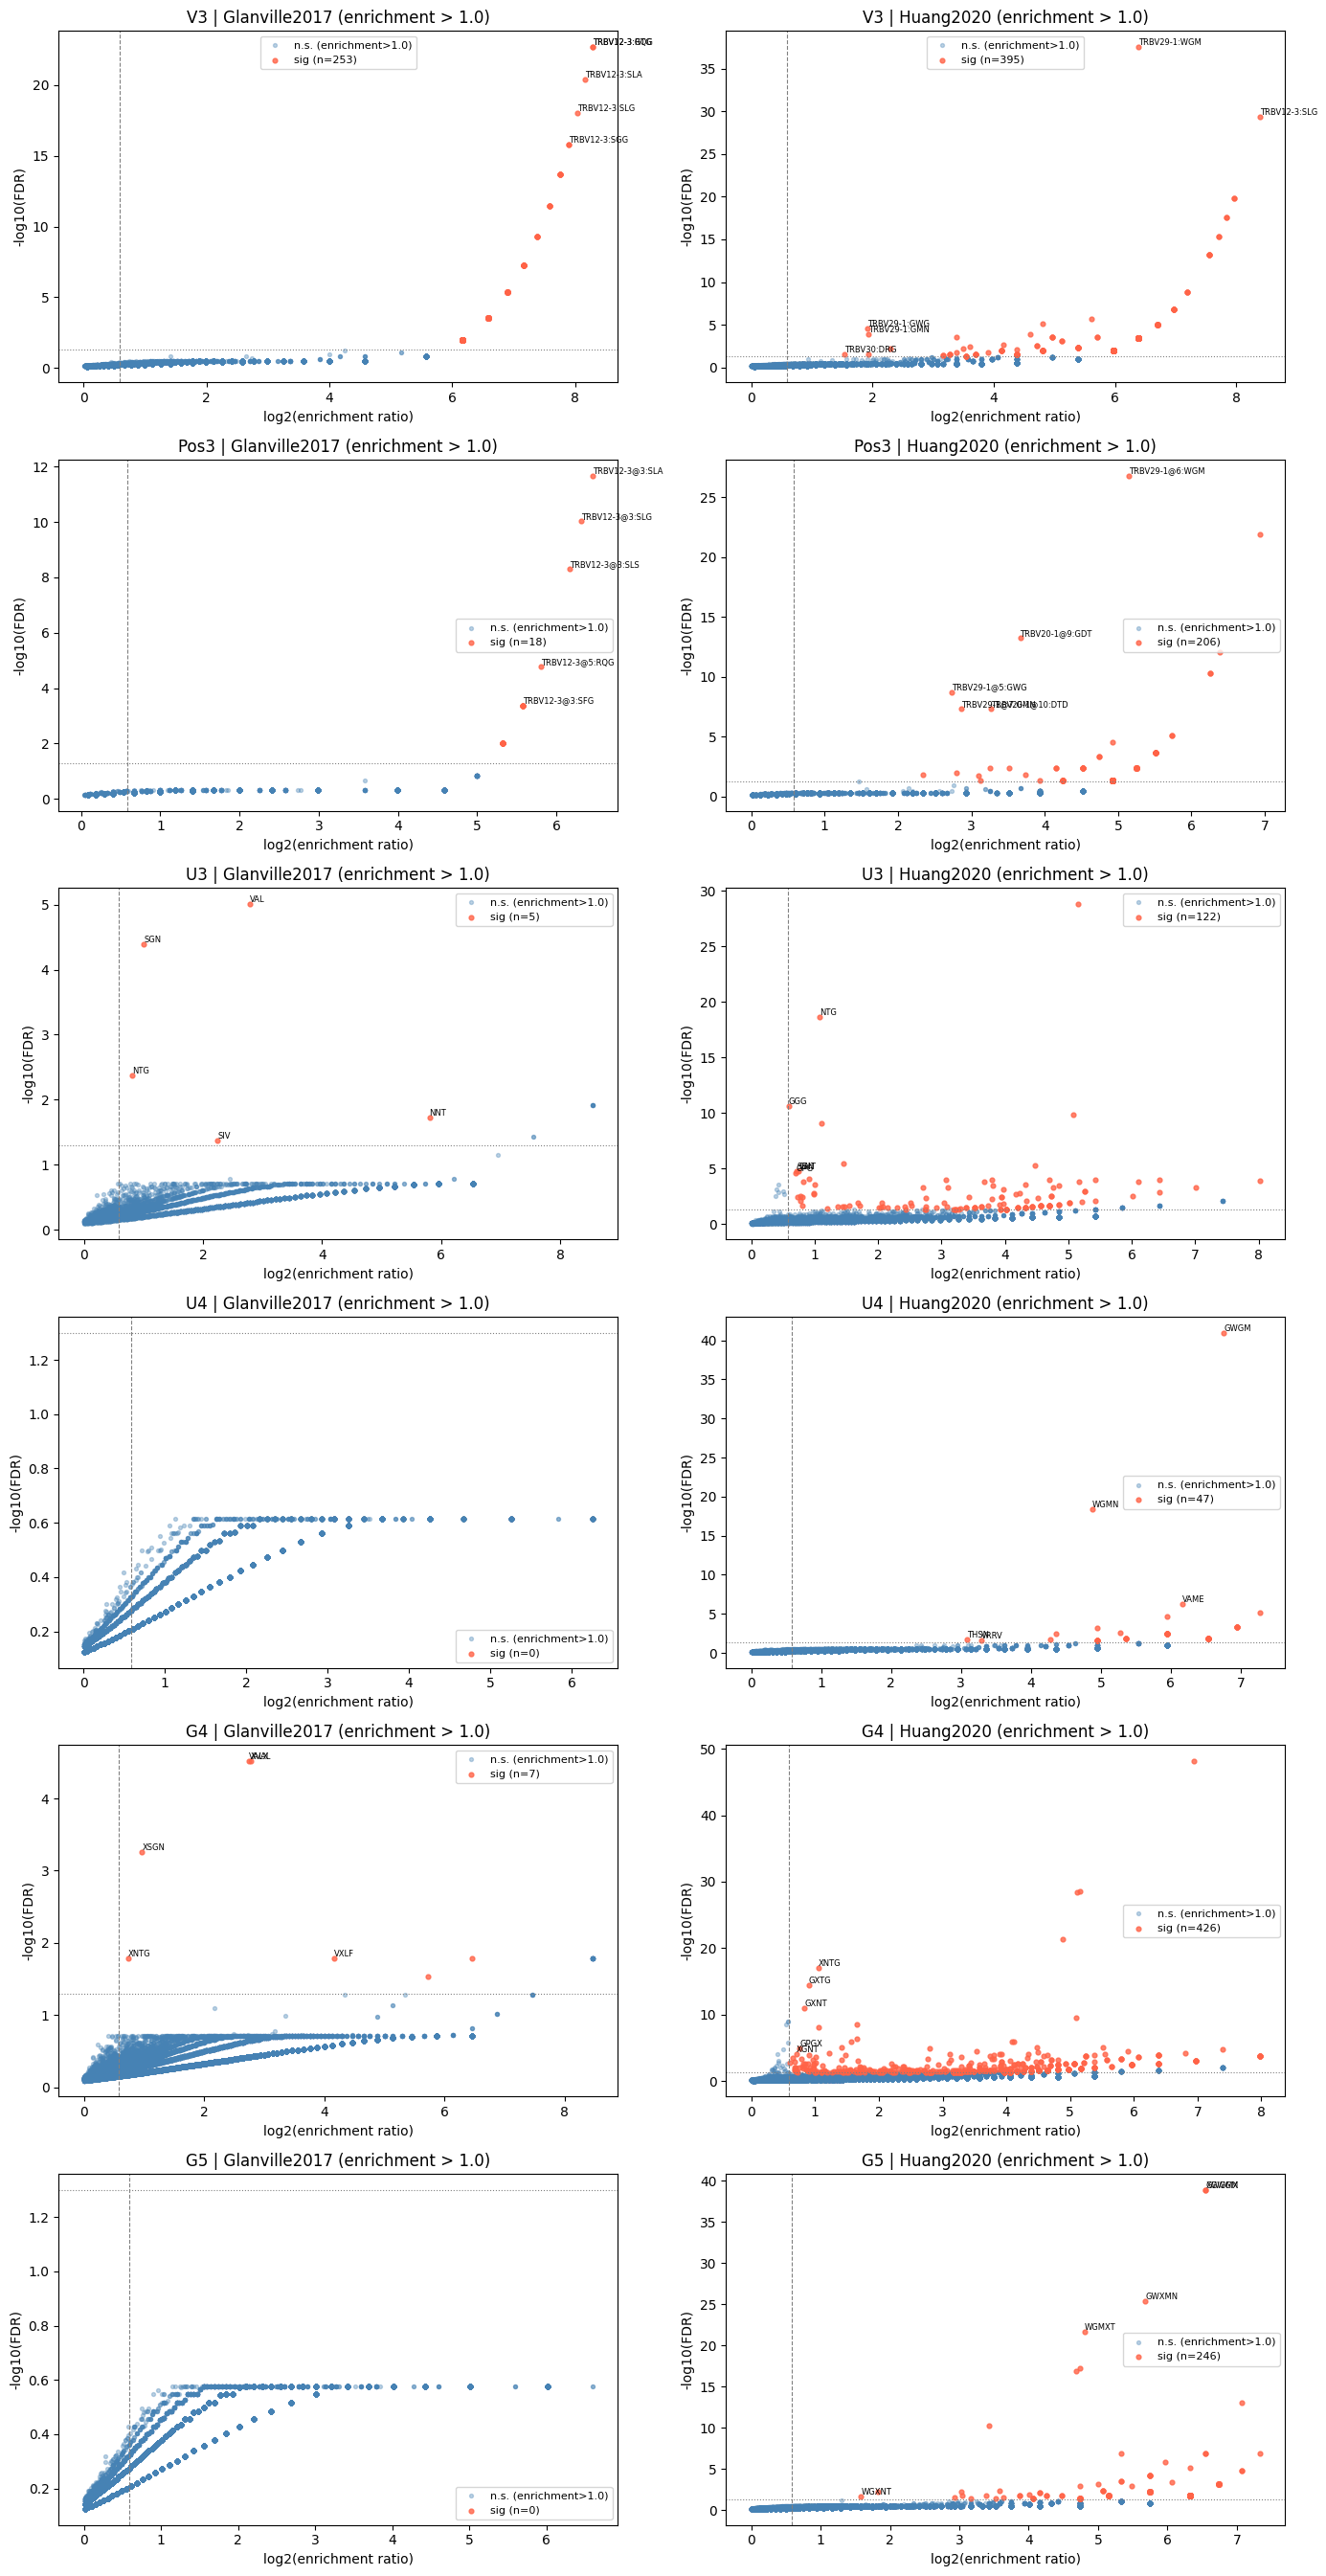

In [8]:
studies = sorted(next(iter(study_results.values())).keys())
n_studies = len(studies)

fig, axes = plt.subplots(
    nrows=len(FAMILIES),
    ncols=n_studies,
    figsize=(7 * n_studies, 4.5 * len(FAMILIES)),
    squeeze=False,
)

for row_i, family in enumerate(FAMILIES):
    for col_i, study in enumerate(studies):
        ax = axes[row_i, col_i]
        comp = study_results[family][study]['comparison'].copy()
        sig = study_results[family][study]['sig_mask']

        comp = comp[comp['freq_fc'] > 1.0].copy()
        sig = sig.reindex(comp.index).fillna(False)
        if comp.empty:
            ax.set_title(f"{FAMILY_LABELS[family]} | {study} (enrichment>1.0: none)")
            ax.axis('off')
            continue

        comp['log2fc'] = np.log2(comp['freq_fc'].clip(lower=1e-6))
        comp['neglog10p'] = -np.log10(comp['p_val_adj'].clip(lower=1e-300))

        ax.scatter(
            comp.loc[~sig, 'log2fc'],
            comp.loc[~sig, 'neglog10p'],
            s=8, alpha=0.35, color='steelblue', label='n.s. (enrichment>1.0)'
        )
        ax.scatter(
            comp.loc[sig, 'log2fc'],
            comp.loc[sig, 'neglog10p'],
            s=12, alpha=0.8, color='tomato', label=f'sig (n={int(sig.sum())})'
        )

        top = comp[sig].nlargest(TOP_LABELS, 'sample_clonotypes')
        for _, row in top.iterrows():
            token_label = _token_display_name(row.name)
            ax.annotate(token_label, xy=(row['log2fc'], row['neglog10p']), fontsize=6, ha='left', va='bottom')

        ax.axvline(np.log2(SIG_ODDS), color='grey', linestyle='--', linewidth=0.8)
        ax.axhline(-np.log10(SIG_FDR), color='grey', linestyle=':', linewidth=0.8)
        ax.set_xlabel('log2(enrichment ratio)')
        ax.set_ylabel('-log10(FDR)')
        ax.set_title(f'{FAMILY_LABELS[family]} | {study} (enrichment > 1.0)')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Full GLIPH Graph and One-Mode Projections

For each study, all enriched k-mers from all five families are merged and used in a full graph workflow:

- Start with token-clonotype edges from enriched k-mers.
- Add clonotype-clonotype edges from Hamming `<= 1` using the mirpy edit-distance graph builder.
- Expand by one Hamming hop: add all Hamming neighbors of already selected clonotypes.
- Build one-mode projections (graph-theory term):
  - clonotype projection (clonotypes connected if they co-occur with shared enriched tokens and/or Hamming edge)
  - k-mer projection (k-mers connected if at least one clonotype carries both)

In [23]:
def _stimulus_color_map(values: pd.Series) -> dict[str, str]:
    unique_values = [v for v in sorted(values.fillna('').astype(str).str.strip().unique()) if v]
    fallback = ['#bc6c25', '#219ebc', '#b5179e', '#588157', '#ff7f11', '#4d908e']
    colors = {}
    for idx, value in enumerate(unique_values):
        colors[value] = STIMULUS_PALETTE.get(value, fallback[idx % len(fallback)])
    return colors


def _token_shape(family: str) -> str:
    shape_map = {
        'v3': 'circle',
        'pos3': 'square',
        'u3': 'triangle-up',
        'u4': 'triangle-down',
        'g4': 'diamond',
        'g5': 'rectangle',
    }
    return shape_map.get(family, 'circle')


def _build_augmented_bipartite_graph(
    study_df: pd.DataFrame,
    token_to_clones: dict[str, set[str]],
    clone_to_tokens: dict[str, set[str]],
    token_family: dict[str, str],
    full_clone_graph: ig.Graph,
) -> ig.Graph:
    token_nodes = sorted(token_to_clones)
    clone_nodes = sorted(str(name) for name in full_clone_graph.vs['name'])
    all_nodes = token_nodes + clone_nodes
    node_idx = {name: i for i, name in enumerate(all_nodes)}

    graph = ig.Graph(n=len(all_nodes), directed=False)
    graph.vs['name'] = all_nodes
    graph.vs['kind'] = ['token'] * len(token_nodes) + ['clone'] * len(clone_nodes)

    edges: list[tuple[int, int]] = []
    edge_kind: list[str] = []
    edge_color: list[str] = []
    edge_width: list[float] = []

    for clone_id, tokens in clone_to_tokens.items():
        if clone_id not in node_idx:
            continue
        for token in sorted(tokens):
            if token not in node_idx:
                continue
            edges.append((node_idx[token], node_idx[clone_id]))
            edge_kind.append('token_clone')
            edge_color.append('#c7c7c7')
            edge_width.append(0.5)

    for edge in full_clone_graph.es:
        left = str(full_clone_graph.vs[edge.source]['name'])
        right = str(full_clone_graph.vs[edge.target]['name'])
        if left not in node_idx or right not in node_idx:
            continue
        edges.append((node_idx[left], node_idx[right]))
        is_hamming = bool(edge['is_hamming']) if 'is_hamming' in full_clone_graph.es.attributes() else False
        shared = int(edge['shared_kmers']) if 'shared_kmers' in full_clone_graph.es.attributes() else 0
        edge_kind.append('clone_hamming' if is_hamming else 'clone_shared')
        edge_color.append('#4d4d4d' if is_hamming else '#8d99ae')
        edge_width.append(0.8 + 0.2 * np.log2(shared + 1.0))

    if edges:
        graph.add_edges(edges)
        graph.es['kind'] = edge_kind
        graph.es['color'] = edge_color
        graph.es['width'] = edge_width

    dup_map = study_df.set_index('row_id')['duplicate_count'].astype(float).to_dict()
    graph.vs['color'] = [
        FAMILY_COLORS.get(token_family.get(v['name'], ''), '#999999') if v['kind'] == 'token' else '#9e9e9e'
        for v in graph.vs
    ]
    graph.vs['shape'] = [
        _token_shape(token_family.get(v['name'], '')) if v['kind'] == 'token' else 'circle'
        for v in graph.vs
    ]

    degree_map = {v['name']: graph.degree(v.index) for v in graph.vs}
    graph.vs['size'] = [
        5.0 + 1.8 * np.log2(degree_map.get(v['name'], 0) + 1.0) if v['kind'] == 'token'
        else 2.0 + 2.2 * np.log2(dup_map.get(v['name'], 1.0) + 1.0)
        for v in graph.vs
    ]
    return graph


def _prepare_clone_graph_style(study_df: pd.DataFrame, clone_graph: ig.Graph) -> ig.Graph:
    graph = clone_graph.copy()
    if graph.vcount() == 0:
        return graph
    dup_map = study_df.set_index('row_id')['duplicate_count'].astype(float).to_dict()
    stimulus_map = study_df.set_index('row_id')['stimulus'].astype(str).to_dict()
    stim_colors = _stimulus_color_map(study_df['stimulus'])
    graph.vs['color'] = [stim_colors.get(stimulus_map.get(str(name), ''), '#bdbdbd') for name in graph.vs['name']]
    graph.vs['shape'] = ['circle'] * graph.vcount()
    graph.vs['size'] = [2.0 + 2.2 * np.log2(dup_map.get(str(name), 1.0) + 1.0) for name in graph.vs['name']]
    if graph.ecount() and 'weight' in graph.es.attributes():
        graph.es['width'] = [0.35 + 0.18 * np.log2(float(weight) + 1.0) for weight in graph.es['weight']]
    else:
        graph.es['width'] = [0.5] * graph.ecount()
    graph.es['kind'] = [
        'clone_hamming' if ('is_hamming' in graph.es.attributes() and bool(edge['is_hamming'])) else 'clone_shared'
        for edge in graph.es
    ]
    graph.es['color'] = ['#4d4d4d' if k == 'clone_hamming' else '#a8dadc' for k in graph.es['kind']]
    return graph


def _project_kmer_graph_with_style(
    study_df: pd.DataFrame,
    token_to_clones: dict[str, set[str]],
    token_family: dict[str, str],
) -> ig.Graph:
    graph, token_degree = build_kmer_projection_graph(token_to_clones)
    if graph.vcount() == 0:
        return graph

    graph.vs['color'] = [FAMILY_COLORS.get(token_family.get(name, ''), '#999999') for name in graph.vs['name']]
    graph.vs['shape'] = [_token_shape(token_family.get(name, '')) for name in graph.vs['name']]
    graph.vs['size'] = [4.0 + 1.6 * np.log2(token_degree.get(name, 0) + 1.0) for name in graph.vs['name']]
    if graph.ecount() and 'weight' in graph.es.attributes():
        graph.es['width'] = [0.35 + 0.15 * np.log2(float(weight) + 1.0) for weight in graph.es['weight']]
    else:
        graph.es['width'] = [0.45] * graph.ecount()
    graph.es['kind'] = ['token_cooccurrence'] * graph.ecount()
    graph.es['color'] = ['#d0d0d0'] * graph.ecount()
    return graph


def _plot_graph(
    graph: ig.Graph,
    title: str,
    *,
    node_legend_items: list[tuple[str, str]] | None = None,
    edge_legend_items: list[tuple[str, str]] | None = None,
    label_nodes: list[str] | None = None,
    label_map: dict[str, str] | None = None,
    max_nodes: int = MAX_GRAPH_NODES,
) -> None:
    from matplotlib.lines import Line2D

    if graph.vcount() == 0:
        print(f'{title}: no nodes to plot')
        return
    if graph.vcount() > max_nodes:
        print(f'{title}: {graph.vcount()} nodes - subsampling to {max_nodes}')
        keep = sorted(range(graph.vcount()), key=lambda idx: -graph.degree(idx))[:max_nodes]
        graph = graph.induced_subgraph(keep)

    labels = []
    label_nodes = set(label_nodes or [])
    for vertex in graph.vs:
        name = str(vertex['name'])
        if name in label_nodes:
            labels.append(label_map.get(name, name) if label_map else name)
        else:
            labels.append(None)

    layout = graph.layout('fr')
    fig, ax = plt.subplots(figsize=(10, 8))
    ig.plot(
        graph,
        layout=layout,
        target=ax,
        vertex_size=graph.vs['size'] if 'size' in graph.vs.attributes() else 6,
        vertex_color=graph.vs['color'] if 'color' in graph.vs.attributes() else '#9e9e9e',
        vertex_shape=graph.vs['shape'] if 'shape' in graph.vs.attributes() else 'circle',
        vertex_label=labels,
        vertex_label_size=8,
        edge_width=graph.es['width'] if 'width' in graph.es.attributes() else 0.5,
        edge_color=graph.es['color'] if 'color' in graph.es.attributes() else '#cccccc',
    )
    ax.set_title(title)

    handles = []
    if node_legend_items:
        handles.extend([mpatches.Patch(color=color, label=label) for label, color in node_legend_items])
    if edge_legend_items:
        handles.extend([
            Line2D([0], [0], color=color, lw=2.0, label=label)
            for label, color in edge_legend_items
        ])
    if handles:
        ax.legend(handles=handles, loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()


def _top_token_labels(token_to_clones: dict[str, set[str]], top_n: int = TOP_LABELS) -> list[str]:
    ranked = sorted(token_to_clones, key=lambda token: (-len(token_to_clones[token]), token))[:top_n]
    return ranked


def _top_clone_labels(study_df: pd.DataFrame, clone_ids: list[str], top_n: int = TOP_LABELS) -> list[str]:
    dup_map = study_df.set_index('row_id')['duplicate_count'].astype(float).to_dict()
    return sorted(clone_ids, key=lambda clone_id: (-dup_map.get(clone_id, 0.0), clone_id))[:top_n]


Skipping sequence with non-canonical amino acid: CASSYXQGVRGRLYGYTF
Skipping sequence with non-canonical amino acid: CASSFPIXLAGTRNTGELFF



=== Glanville2017 | full GLIPH graphs ===
Enriched token counts by family: {'v3': 253, 'pos3': 18, 'u3': 5, 'u4': 0, 'g4': 7, 'g5': 0}
Combined enriched token total: 283
Initial token-linked clonotypes: 426
Full hamming graph: 3930 nodes / 182 edges
Expanded full clone graph: 447 nodes / 398 edges


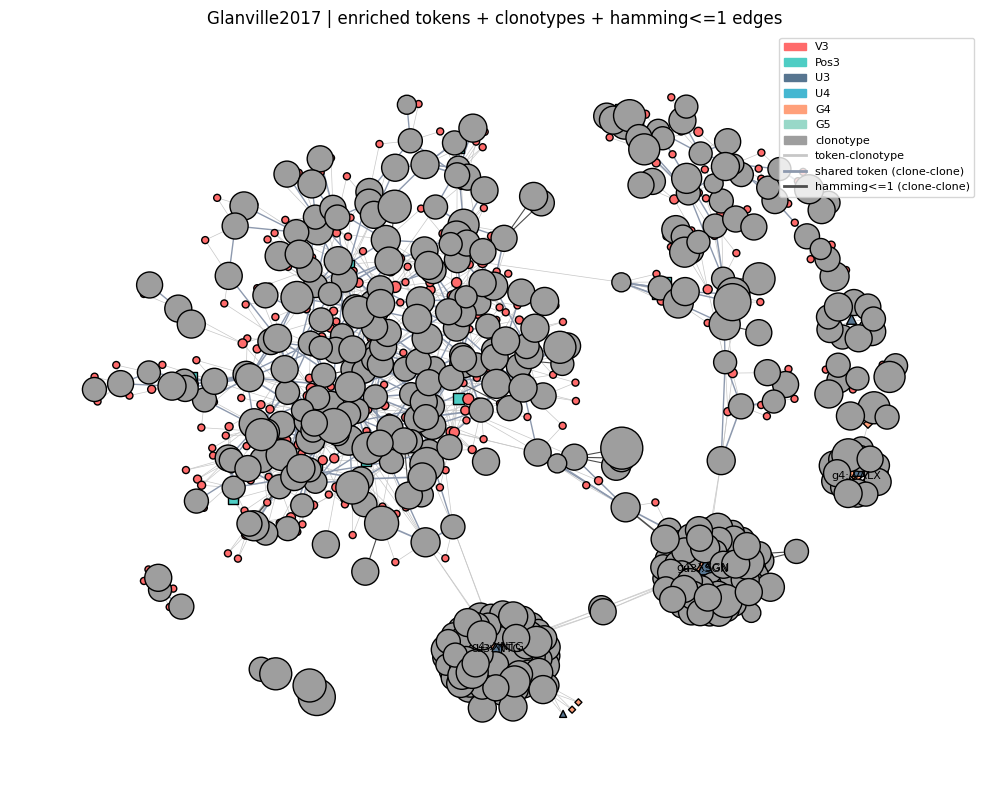

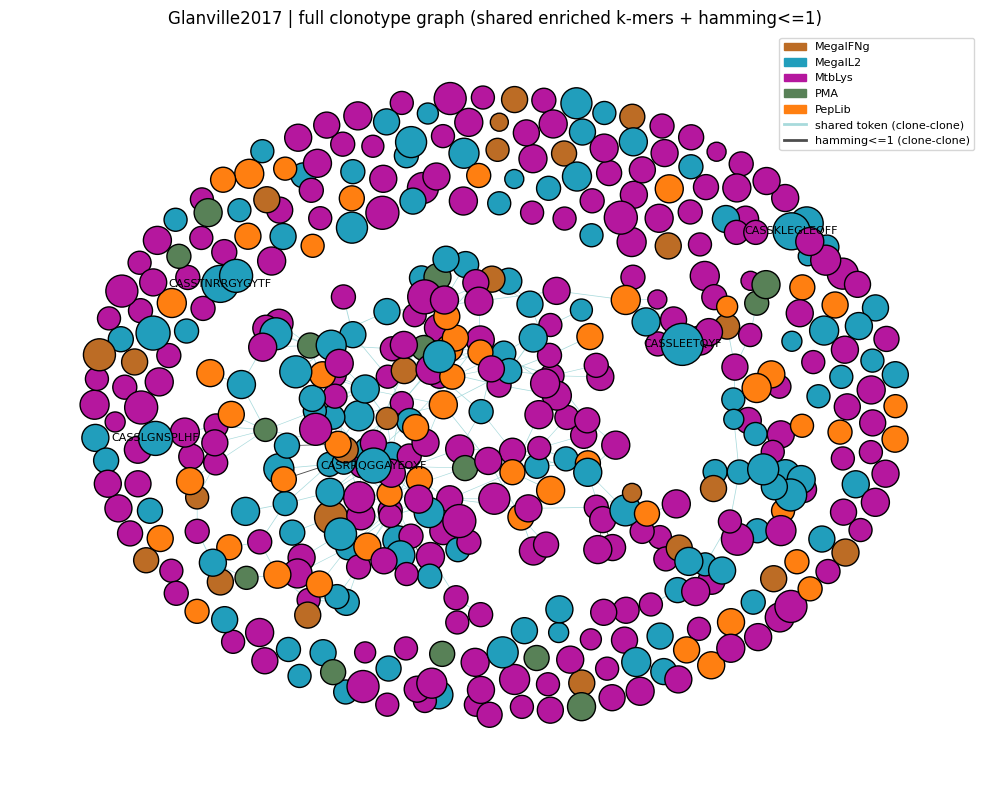

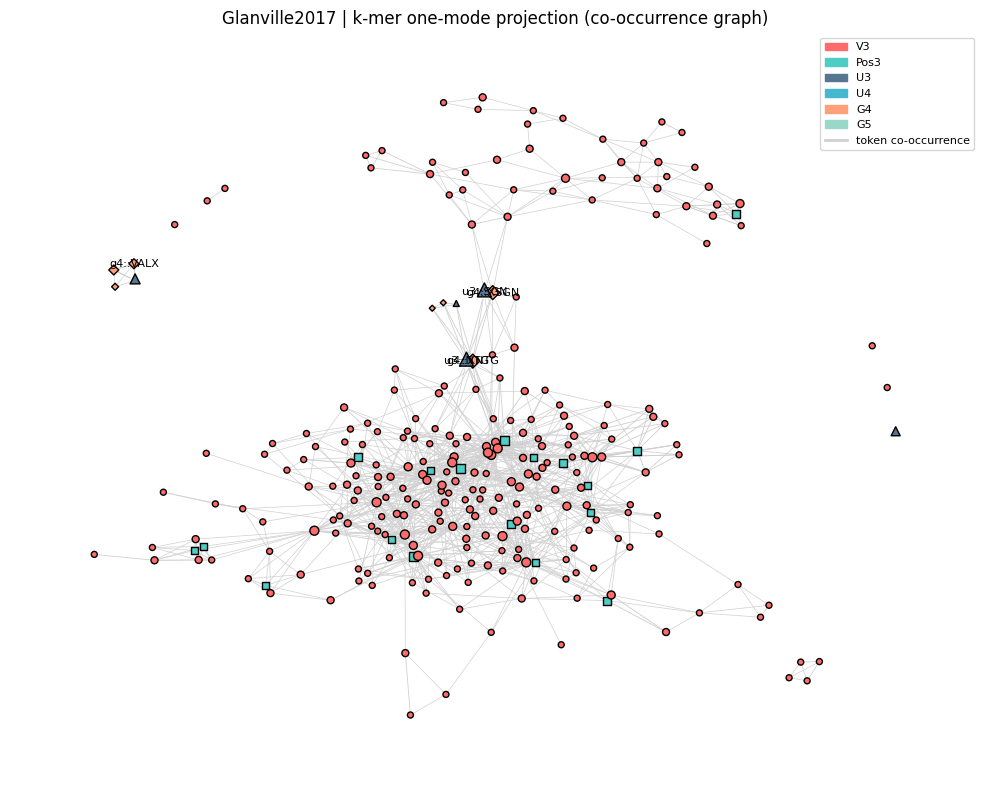


=== Huang2020 | full GLIPH graphs ===
Enriched token counts by family: {'v3': 395, 'pos3': 206, 'u3': 122, 'u4': 47, 'g4': 426, 'g5': 246}
Combined enriched token total: 1442
Initial token-linked clonotypes: 3345
Full hamming graph: 9934 nodes / 1725 edges
Expanded full clone graph: 3514 nodes / 2498 edges
Huang2020 | enriched tokens + clonotypes + hamming<=1 edges: 4956 nodes - subsampling to 800


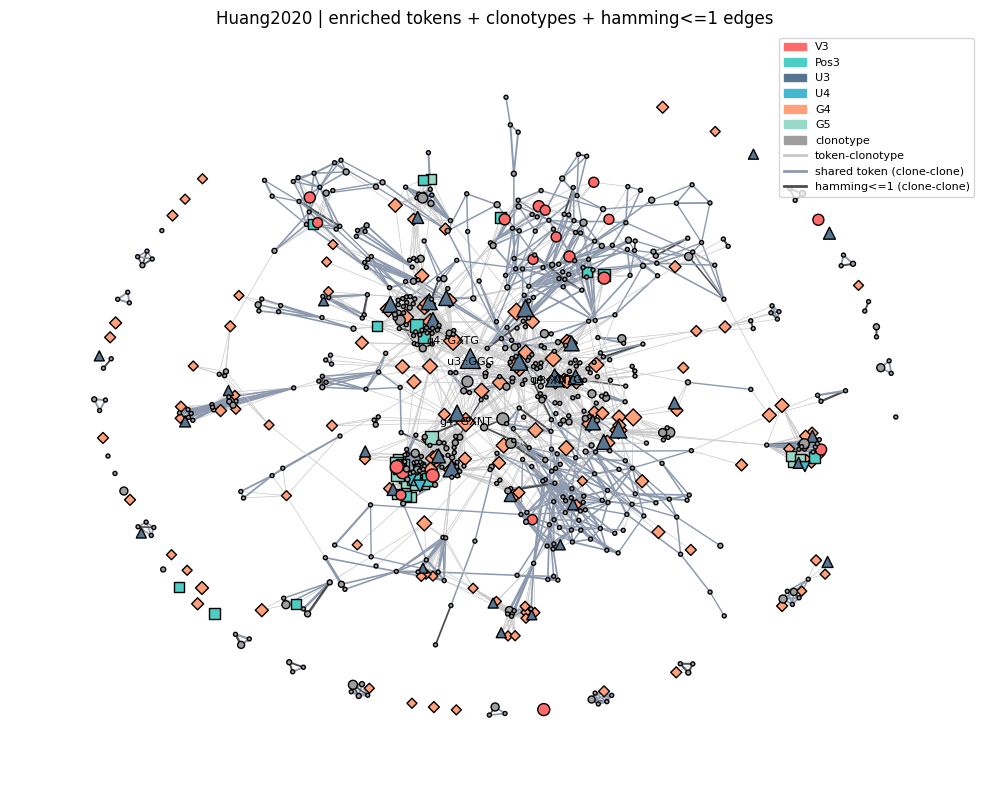

Huang2020 | full clonotype graph (shared enriched k-mers + hamming<=1): 3514 nodes - subsampling to 800


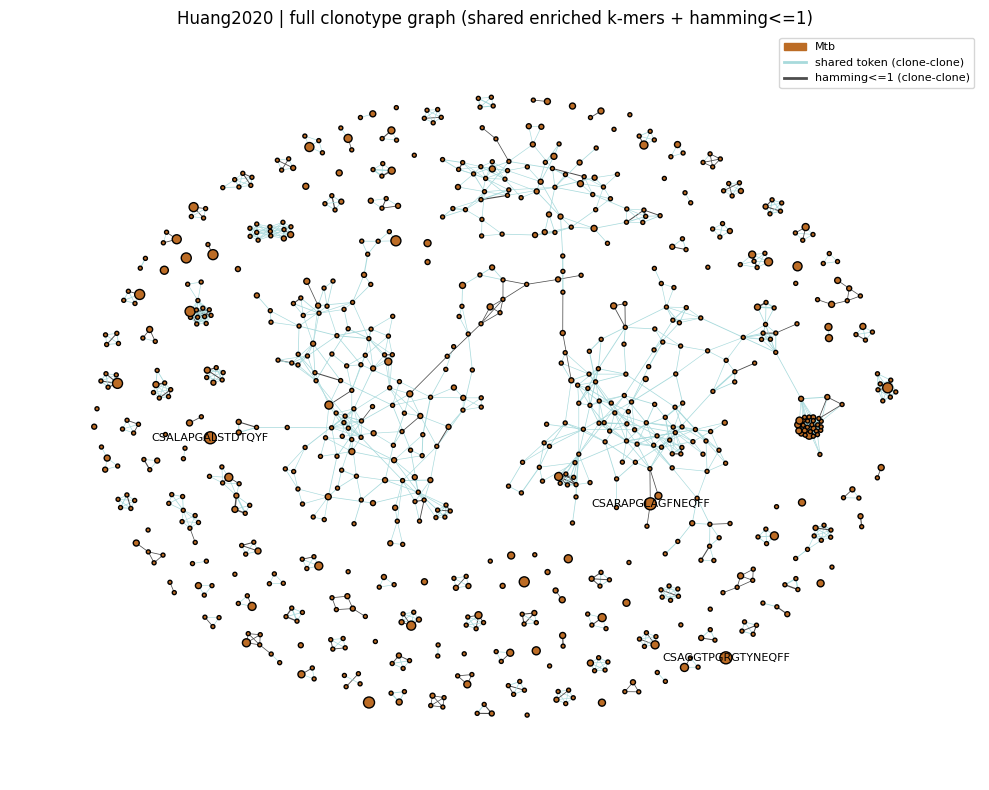

Huang2020 | k-mer one-mode projection (co-occurrence graph): 1442 nodes - subsampling to 800


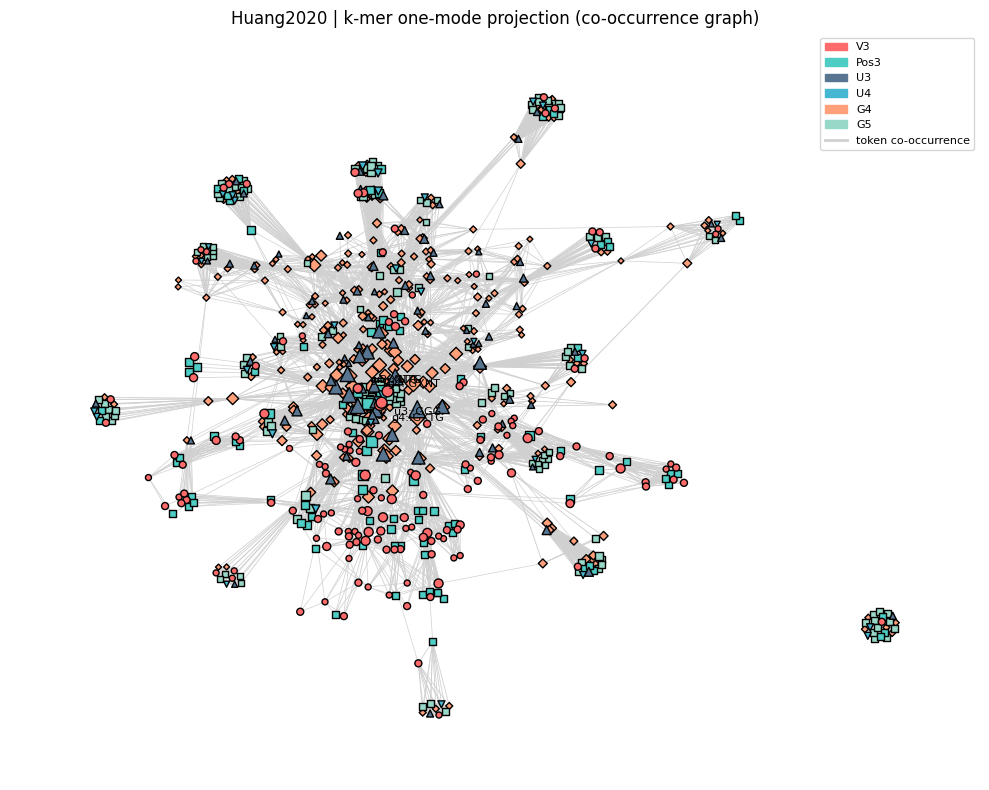

In [25]:
combined_graph_payloads: dict[str, dict[str, object]] = {}

for study in sorted(next(iter(study_results.values())).keys()):
    study_payloads = {family: study_results[family][study] for family in FAMILIES}
    study_df = study_payloads[FAMILIES[0]]['study_df']

    artifacts_by_family = {family: study_payloads[family]['study_art'] for family in FAMILIES}
    enriched_by_family = {family: study_payloads[family]['enriched_tokens'] for family in FAMILIES}
    token_to_clones, clone_to_tokens, token_family = combine_enriched_token_maps(
        artifacts_by_family,
        enriched_by_family,
    )

    full_clone_graph, clone_to_tokens_expanded, hamming_graph = build_full_gliph_clonotype_graph(
        study_df,
        token_to_clones,
        hamming_threshold=1,
        hamming_threads=TOKEN_THREADS,
        expand_hamming_neighbors=True,
        min_kmer_edge_weight=CLONE_EDGE_MIN_WEIGHT,
    )

    combined_graph_payloads[study] = {
        'study_df': study_df,
        'token_to_clones': token_to_clones,
        'clone_to_tokens': clone_to_tokens_expanded,
        'token_family': token_family,
        'full_clone_graph': full_clone_graph,
        'hamming_graph': hamming_graph,
    }

    print(f'\n=== {study} | full GLIPH graphs ===')
    family_counts = {family: len(study_payloads[family]['enriched_tokens']) for family in FAMILIES}
    print('Enriched token counts by family:', family_counts)
    print('Combined enriched token total:', len(token_to_clones))
    print('Initial token-linked clonotypes:', len(clone_to_tokens))
    print('Full hamming graph:', hamming_graph.vcount(), 'nodes /', hamming_graph.ecount(), 'edges')
    print('Expanded full clone graph:', full_clone_graph.vcount(), 'nodes /', full_clone_graph.ecount(), 'edges')

    bipartite_graph = _build_augmented_bipartite_graph(
        study_df,
        token_to_clones,
        clone_to_tokens_expanded,
        token_family,
        full_clone_graph,
    )
    _plot_graph(
        bipartite_graph,
        title=f'{study} | enriched tokens + clonotypes + hamming<=1 edges',
        node_legend_items=[(FAMILY_LABELS[family], FAMILY_COLORS[family]) for family in FAMILIES] + [('clonotype', '#9e9e9e')],
        edge_legend_items=[
            ('token-clonotype', '#c7c7c7'),
            ('shared token (clone-clone)', '#8d99ae'),
            ('hamming<=1 (clone-clone)', '#4d4d4d'),
        ],
        label_nodes=_top_token_labels(token_to_clones),
    )

    clone_graph = _prepare_clone_graph_style(study_df, full_clone_graph)
    stim_legend = [(label, color) for label, color in _stimulus_color_map(study_df['stimulus']).items()]
    clone_label_map = (
        study_df.assign(row_id=study_df['row_id'].astype(str))
        .drop_duplicates('row_id')
        .set_index('row_id')['junction_aa']
        .astype(str)
        .to_dict()
    )
    top_clone_ids = _top_clone_labels(study_df, [str(name) for name in clone_graph.vs['name']])
    _plot_graph(
        clone_graph,
        title=f'{study} | full clonotype graph (shared enriched k-mers + hamming<=1)',
        node_legend_items=stim_legend,
        edge_legend_items=[
            ('shared token (clone-clone)', '#a8dadc'),
            ('hamming<=1 (clone-clone)', '#4d4d4d'),
        ],
        label_nodes=top_clone_ids,
        label_map=clone_label_map,
    )

    kmer_graph = _project_kmer_graph_with_style(study_df, token_to_clones, token_family)
    _plot_graph(
        kmer_graph,
        title=f'{study} | k-mer one-mode projection (co-occurrence graph)',
        node_legend_items=[(FAMILY_LABELS[family], FAMILY_COLORS[family]) for family in FAMILIES],
        edge_legend_items=[('token co-occurrence', '#d0d0d0')],
        label_nodes=_top_token_labels(token_to_clones),
    )


In [17]:
def _canonical_study_name(study_name: str) -> str | None:
    s = str(study_name).lower()
    for canon, keyword in STUDY_KEYWORDS.items():
        if keyword in s:
            return canon
    return None


def _purity_score(y_true: pd.Series, y_pred: pd.Series) -> float:
    tab = pd.crosstab(y_pred, y_true)
    if tab.empty:
        return float('nan')
    return float(tab.max(axis=1).sum() / tab.to_numpy().sum())


def _cluster_projected_graph(
    study_df: pd.DataFrame,
    clone_graph: ig.Graph,
    method: str,
    min_cluster_size: int = MIN_CLUSTER_SIZE,
) -> tuple[dict[str, int], dict[str, int]]:
    clone_ids_all = study_df['row_id'].astype(str).tolist()
    labels_all = {clone_id: -1 for clone_id in clone_ids_all}
    if clone_graph.vcount() == 0 or clone_graph.ecount() == 0:
        return labels_all, {'n_clusters': 0, 'n_clustered': 0, 'n_total': len(clone_ids_all)}

    if method == 'components':
        membership = np.full(clone_graph.vcount(), -1, dtype=int)
        for comp_id, vertices in enumerate(clone_graph.components()):
            for vertex in vertices:
                membership[vertex] = comp_id
    elif method == 'leiden':
        membership = np.array(
            clone_graph.community_leiden(weights='weight', objective_function='modularity', n_iterations=5).membership,
            dtype=int,
        )
    else:
        raise ValueError(f'Unknown method: {method}')

    keep_mask = np.zeros_like(membership, dtype=bool)
    for label in np.unique(membership):
        if (membership == label).sum() >= min_cluster_size:
            keep_mask |= (membership == label)
    membership = np.where(keep_mask, membership, -1)

    for clone_id, label in zip(clone_graph.vs['name'], membership):
        labels_all[str(clone_id)] = int(label)

    stats = {
        'n_clusters': int(len(set(membership[membership >= 0]))),
        'n_clustered': int((membership >= 0).sum()),
        'n_total': len(clone_ids_all),
    }
    return labels_all, stats


def _make_cluster_table(
    study_df: pd.DataFrame,
    clone_to_tokens: dict[str, set[str]],
    token_family: dict[str, str],
    labels_map: dict[str, int],
    top_n: int = 15,
) -> pd.DataFrame:
    rows = []
    study_index = study_df.set_index('row_id')
    valid_labels = sorted({label for label in labels_map.values() if label >= 0})
    for label in valid_labels:
        member_ids = [clone_id for clone_id, value in labels_map.items() if value == label]
        member_rows = study_index.loc[study_index.index.intersection(member_ids)]
        token_support = Counter()
        family_support = Counter()
        for clone_id in member_ids:
            for token in clone_to_tokens.get(clone_id, set()):
                token_support[token] += 1
                family_support[token_family.get(token, _family_from_token(token))] += 1
        top_tokens = ', '.join(
            f"{_token_display_name(token)} ({count})"
            for token, count in token_support.most_common(5)
        )
        top_families = ', '.join(f'{FAMILY_LABELS[family]}:{count}' for family, count in family_support.most_common())
        rows.append({
            'cluster': label,
            'size': len(member_ids),
            'mean_duplicate_count': float(member_rows['duplicate_count'].mean()) if len(member_rows) else np.nan,
            'top_families': top_families,
            'top_enriched_tokens': top_tokens,
            'stimuli': ', '.join(member_rows['stimulus'].astype(str).value_counts().head(3).index.tolist()),
            'sequences': ' | '.join(member_rows['junction_aa'].astype(str).tolist()[:5]),
        })
    if not rows:
        return pd.DataFrame(columns=['cluster', 'size', 'mean_duplicate_count', 'top_families', 'top_enriched_tokens', 'stimuli', 'sequences'])
    return pd.DataFrame(rows).sort_values('size', ascending=False).head(top_n)


def _concordance_row(
    study_df: pd.DataFrame,
    labels_map: dict[str, int],
    target_col: str,
    target_name: str,
    canonical_study: str | None,
    method: str,
) -> dict[str, object]:
    tmp = study_df[['row_id', target_col]].copy()
    tmp['target'] = tmp[target_col].fillna('').astype(str).str.strip()
    tmp = tmp[~tmp['target'].str.lower().isin({'', 'nan', 'none', 'na'})].copy()

    if target_col == 'gliph_cluster_id' and not tmp.empty:
        target_sizes = tmp['target'].value_counts()
        keep = target_sizes[target_sizes >= 3].index
        tmp = tmp[tmp['target'].isin(keep)].copy()

    n_target_total = len(tmp)
    if n_target_total == 0:
        return {
            'canonical_study': canonical_study,
            'reference_id': str(study_df['reference_id'].iloc[0]),
            'method': method,
            'config': f'full_gliph+{method}',
            'target_name': target_name,
            'n_total': len(study_df),
            'n_target_total': 0,
            'n_eval': 0,
            'coverage': 0.0,
            'ami': np.nan,
            'nmi': np.nan,
            'ari': np.nan,
            'purity': np.nan,
        }

    tmp['pred_cluster'] = tmp['row_id'].map(labels_map).fillna(-1).astype(int)
    coverage = float((tmp['pred_cluster'] >= 0).mean())
    eval_df = tmp[tmp['pred_cluster'] >= 0].copy()

    if len(eval_df) < 2 or eval_df['pred_cluster'].nunique() < 2 or eval_df['target'].nunique() < 2:
        ami = nmi = ari = purity = np.nan
    else:
        ami = adjusted_mutual_info_score(eval_df['target'], eval_df['pred_cluster'])
        nmi = normalized_mutual_info_score(eval_df['target'], eval_df['pred_cluster'])
        ari = adjusted_rand_score(eval_df['target'], eval_df['pred_cluster'])
        purity = _purity_score(eval_df['target'], eval_df['pred_cluster'])

    return {
        'canonical_study': canonical_study,
        'reference_id': str(study_df['reference_id'].iloc[0]),
        'method': method,
        'config': f'full_gliph+{method}',
        'target_name': target_name,
        'n_total': len(study_df),
        'n_target_total': n_target_total,
        'n_eval': len(eval_df),
        'coverage': coverage,
        'ami': ami,
        'nmi': nmi,
        'ari': ari,
        'purity': purity,
    }


In [18]:
cluster_tables: dict[tuple[str, str], pd.DataFrame] = {}
cluster_labels: dict[tuple[str, str], dict[str, int]] = {}
cluster_stats_rows: list[dict[str, object]] = []
concordance_rows: list[dict[str, object]] = []

for study, payload in combined_graph_payloads.items():
    study_df = payload['study_df']
    clone_to_tokens = payload['clone_to_tokens']
    token_family = payload['token_family']
    full_clone_graph = payload['full_clone_graph']
    canonical = _canonical_study_name(study)
    total_enriched = len(payload['token_to_clones'])
    n_hamming_edges = int(sum(bool(v) for v in full_clone_graph.es['is_hamming'])) if (full_clone_graph.ecount() and 'is_hamming' in full_clone_graph.es.attributes()) else 0

    for method in CLUSTER_METHODS:
        labels_map, stats = _cluster_projected_graph(
            study_df,
            full_clone_graph,
            method=method,
            min_cluster_size=MIN_CLUSTER_SIZE,
        )
        cluster_labels[(study, method)] = labels_map
        cluster_tables[(study, method)] = _make_cluster_table(study_df, clone_to_tokens, token_family, labels_map)

        cluster_stats_rows.append({
            'canonical_study': canonical,
            'reference_id': study,
            'method': method,
            'config': f'full_gliph+{method}',
            'n_enriched_tokens_total': total_enriched,
            'n_full_graph_nodes': int(full_clone_graph.vcount()),
            'n_full_graph_edges': int(full_clone_graph.ecount()),
            'n_hamming_edges': n_hamming_edges,
            'n_clusters': stats['n_clusters'],
            'n_clustered': stats['n_clustered'],
            'n_total': stats['n_total'],
            'clustered_frac': stats['n_clustered'] / stats['n_total'] if stats['n_total'] else np.nan,
        })

        concordance_rows.append(_concordance_row(
            study_df=study_df,
            labels_map=labels_map,
            target_col='gliph_cluster_id',
            target_name='gliph_cluster_id',
            canonical_study=canonical,
            method=method,
        ))

        # Keep epitope for Glanville only when present; remove epitope from Huang.
        if canonical == 'Glanville2017':
            concordance_rows.append(_concordance_row(
                study_df=study_df,
                labels_map=labels_map,
                target_col='stimulus',
                target_name='stimulus',
                canonical_study=canonical,
                method=method,
            ))
            concordance_rows.append(_concordance_row(
                study_df=study_df,
                labels_map=labels_map,
                target_col='epitope',
                target_name='epitope',
                canonical_study=canonical,
                method=method,
            ))

cluster_stats_df = pd.DataFrame(cluster_stats_rows).sort_values(
    ['canonical_study', 'reference_id', 'method']
).reset_index(drop=True)
concordance_df = pd.DataFrame(concordance_rows).sort_values(
    ['canonical_study', 'reference_id', 'target_name', 'method']
).reset_index(drop=True)

print('Cluster statistics table:')
display(cluster_stats_df)

print('Concordance table:')
display(concordance_df)


Cluster statistics table:


,canonical_study,reference_id,method,config,n_enriched_tokens_total,n_full_graph_nodes,n_full_graph_edges,n_hamming_edges,n_clusters,n_clustered,n_total,clustered_frac
0,Glanville2017,Glanville2017,components,full_gliph+components,283,447,398,42,15,266,3930,0.067684
1,Glanville2017,Glanville2017,leiden,full_gliph+leiden,283,447,398,42,30,266,3930,0.067684
2,Huang2020,Huang2020,components,full_gliph+components,1442,3514,2498,837,470,1831,9934,0.184316
3,Huang2020,Huang2020,leiden,full_gliph+leiden,1442,3514,2498,837,482,1831,9934,0.184316


Concordance table:


,canonical_study,reference_id,method,config,target_name,n_total,n_target_total,n_eval,coverage,ami,nmi,ari,purity
0,Glanville2017,Glanville2017,components,full_gliph+components,epitope,3930,0,0,0.000000,NaN,NaN,NaN,NaN
1,Glanville2017,Glanville2017,leiden,full_gliph+leiden,epitope,3930,0,0,0.000000,NaN,NaN,NaN,NaN
2,Glanville2017,Glanville2017,components,full_gliph+components,gliph_cluster_id,3930,260,40,0.153846,0.509085,0.695955,0.210629,0.500000
3,Glanville2017,Glanville2017,leiden,full_gliph+leiden,gliph_cluster_id,3930,260,40,0.153846,0.846705,0.934794,0.733333,0.825000
4,Glanville2017,Glanville2017,components,full_gliph+components,stimulus,3930,3930,266,0.067684,-0.012522,0.064270,-0.023301,0.511278
5,Glanville2017,Glanville2017,leiden,full_gliph+leiden,stimulus,3930,3930,266,0.067684,-0.000121,0.097485,0.000321,0.541353
6,Huang2020,Huang2020,components,full_gliph+components,gliph_cluster_id,9934,1202,569,0.473378,0.744621,0.923919,0.320982,0.831283
7,Huang2020,Huang2020,leiden,full_gliph+leiden,gliph_cluster_id,9934,1202,569,0.473378,0.842075,0.958369,0.739299,0.884007



=== full GLIPH graph + components | Glanville2017 ===


,cluster,size,mean_duplicate_count,top_families,top_enriched_tokens,stimuli,sequences
0,0,187,5246.037433,"V3:583, Pos3:80, G4:6, U3:6","TRBV12-3:RQG (11), TRBV12-3:GTG (11), TRBV12-3...","MtbLys, MegaIL2, PepLib",CASRRQGGAYEQYF | CASTNSGSNQPQHF | CASSLVTAGNTI...
1,1,39,3036.538462,"V3:93, Pos3:5, G4:1, U3:1","TRBV6-2:TGT (5), TRBV6-2@5:TGT (5), TRBV6-2:GT...","MtbLys, MegaIL2, PepLib",CASRGTGTGNYGYTF | CASRGTGRTGNTIYF | CASSPQSGYT...
3,10,8,14089.000000,"V3:18, Pos3:8","TRBV12-3:SLI (4), TRBV12-3@3:SLI (4), TRBV12-3...","MegaIL2, MtbLys",CASSKLEGLEQFF | CASSQLENTEAFF | CASSLIENTEAFF ...
2,4,4,1854.750000,"G4:3, U3:3","XSGN (3), SGN (3)","MtbLys, MegaIL2",CASSLSPGSGNTIYF | CASSPSPGSGNTIYF | CASSLSPGSG...
4,20,4,3774.000000,V3:8,"TRBV6-2:GHY (2), TRBV6-2:QGH (2), TRBV6-2:GQG ...","MtbLys, MegaIL2",CASSSGQGHYNEQFF | CASSVGQGHYNEQFF | CASSLGQGHY...
11,52,4,1988.000000,V3:4,"TRBV6-2:SQG (2), TRBV6-2:DRA (2)","MtbLys, MegaIL2, PepLib",CASSPGDRAHQPQHF | CASSQGDRAHQPQHF | CASSQGLSTQ...
7,30,3,1804.666667,V3:8,"TRBV6-2:RGF (2), TRBV6-2:DRG (2), TRBV6-2:RDR ...",MtbLys,CASRFRDRGFSAEKLFF | CASSYTIRDRGFGTEAFF | CASSY...
12,54,3,5343.666667,V3:9,"TRBV12-3:SSS (2), TRBV12-3:TGE (2), TRBV12-3:S...","MtbLys, MegaIL2",CASSSSGTGEKLFF | CASSGWTGEETQYF | CASSSSGTKYNEQFF
5,21,2,2712.500000,V3:3,"TRBV12-3:RTA (2), TRBV12-3:SRT (1)","MegaIL2, MtbLys",CASGRTAVQPQHF | CASSRTAATGEQFF
6,26,2,2082.500000,"G4:4, U3:2","VAL (2), XVAL (2), VALX (2)","MtbLys, MegaIFNg",CASSVALAGNTIYF | CASSVALLGNTIYF



=== full GLIPH graph + leiden | Glanville2017 ===


,cluster,size,mean_duplicate_count,top_families,top_enriched_tokens,stimuli,sequences
3,3,26,3419.038462,"V3:69, Pos3:5, G4:1, U3:1","TRBV6-2:TGT (5), TRBV6-2@5:TGT (5), TRBV6-2:GT...","MegaIL2, MtbLys, PepLib",CASRGTGTGNYGYTF | CASRGTGRTGNTIYF | CASSESGGSN...
13,22,20,2302.400000,"V3:70, Pos3:14","TRBV12-3@3:SFR (5), TRBV12-3:SFR (5), TRBV12-3...","MtbLys, MegaIL2, PepLib",CASSRDGRGPGNTIYF | CASSFRTSGETQYF | CASSFRGFMN...
4,4,19,3150.315789,"V3:41, Pos3:5","TRBV12-3:SLV (4), TRBV12-3@3:SLV (4), TRBV12-3...","MtbLys, MegaIL2, MegaIFNg",CASSLVTAGNTIYF | CASSPGLTSWSSTDTQYF | CASSLSQP...
1,1,18,3496.944444,"V3:55, Pos3:8","TRBV12-3@3:SFG (5), TRBV12-3:SFG (5), TRBV12-3...","MtbLys, MegaIL2, PepLib",CASSFGAIYGEQYF | CASRLGGLAEDEQFF | CASRYRHRDAL...
6,7,16,3439.750000,"V3:53, Pos3:10","TRBV12-3@3:SLA (6), TRBV12-3:SLA (6), TRBV12-3...","MtbLys, MegaIL2, PepLib",CASSKKVAGGTGELFF | CASSSLERVSSKVLYNQPQHF | CAS...
17,34,15,3824.333333,"V3:38, Pos3:7","TRBV12-3:SFS (5), TRBV12-3@3:SFS (5), TRBV12-3...","MtbLys, MegaIL2, PMA",CASSFSRGKNIQYF | CASSFSEVNEQFF | CASSFSSGSADTQ...
26,70,14,3550.785714,"V3:38, Pos3:3","TRBV12-3:SPR (3), TRBV12-3:PRL (2), TRBV12-3@3...","MtbLys, PepLib, MegaIL2",CASSPRLTPYEQYF | CASSLSAGQAFF | CASSKGTVTDTQYF...
2,2,14,3930.357143,"V3:52, Pos3:11","TRBV12-3:LGQ (4), TRBV12-3@3:SLG (4), TRBV12-3...","MtbLys, MegaIL2, PepLib",CASSLGQGRGGYTF | CASSLGQTSYNSPLHF | CASSEGVNEQ...
0,0,13,7373.692308,"V3:54, Pos3:11","TRBV12-3@4:RQG (5), TRBV12-3:RQG (5), TRBV12-3...","MegaIL2, MtbLys, PepLib",CASRRQGGAYEQYF | CASSRQGGITDTQYF | CASLRASGANV...
9,13,13,4538.461538,"V3:45, Pos3:4, U3:2, G4:2","TRBV12-3:RGQ (4), TRBV12-3:SRG (3), TRBV12-3:G...","MtbLys, PepLib, MegaIL2",CASTNSGSNQPQHF | CASSLGNTGELFF | CASSLGNSPLHF ...



=== full GLIPH graph + components | Huang2020 ===


...


=== full GLIPH graph + leiden | Huang2020 ===


,cluster,size,mean_duplicate_count,top_families,top_enriched_tokens,stimuli,sequences
37,85,94,1.308511,"V3:232, G4:65, Pos3:58, U3:31, G5:6","TRBV12-3@3:SLG (12), TRBV12-3:SLG (12), TRBV12...",Mtb,CASSPLVAGSSYEQYF | CASTHGLAVYNEQFF | CAIREGSYN...
39,88,90,1.444444,"G4:299, U3:105, G5:31, V3:22, Pos3:21, U4:8","CGXG (9), GGG (8), SCGX (8), SCG (8), RGC (7)",Mtb,CASCGSSYNSPLHF | CSARAPGLAGFNEQFF | CACSVAFCGN...
41,92,84,1.476190,"V3:200, Pos3:59, G4:49, U3:29, G5:3","GGG (11), TRBV6-2:SYN (10), TRBV6-2@3:SYS (8),...",Mtb,CASRSRGGRTYNEQFF | CASRSGLMNTEAFF | CASSRGQGLF...
18,47,61,1.377049,"V3:169, Pos3:80, U3:14, G4:13","GGG (9), TRBV12-3:GGG (7), TRBV12-3:GGA (7), T...",Mtb,CASHSLANRGIRVASGELFF | CASRTGQVVDTQYF | CASRTG...
28,73,33,1.787879,"G4:102, U3:39, G5:14, V3:6, U4:4","SCXR (4), CGR (4), XCGR (4), CGRX (4), CXRG (4)",Mtb,CASSLVGHEVCREETQYF | CASSSREGRDGYTF | CACSGGVC...
98,249,31,1.645161,"G4:357, G5:261, U3:118, Pos3:87, V3:83, U4:50","GWXM (30), GXGM (28), WGM (27), XGWGM (27), TR...",Mtb,CSAGPGWGMNTEAFF | CSAKAGWGMSTEAFF | CSVTGGWGMN...
63,150,27,1.296296,"G4:98, G5:50, U3:25, V3:14, U4:13, Pos3:12","RAMX (7), RAM (7), XRAM (7), CLG (5), CLGX (5)",Mtb,CASSPFWGTGELFF | CASNGRAMETQYF | CASSCLQGASGRT...
135,331,18,1.333333,"V3:18, G4:18, U3:11, Pos3:3","GNT (4), XGNT (4), TRBV12-3:RDR (3), TRBV12-3:...",Mtb,CASRRDRKTGELFF | CASSLALNTEAFF | CASSLAMNTEAFF...
47,104,18,1.055556,"G4:25, V3:16, U3:12","SCTX (3), SCT (3), TRBV6-2:DSN (3), XGAC (3), ...",Mtb,CASSCTAGGTEAFF | CASSCTRDSNSPLHF | CASSFTRDSNS...
145,356,17,1.352941,"G4:36, U3:16","GXNT (13), GNT (4), XGNT (4), MNT (3), XMNT (3)",Mtb,CARRPGGNTEAFF | CASSQTMNTEAFF | CASSPEGNTEAFF ...


,canonical_study,reference_id,method,config,target_name,n_total,n_target_total,n_eval,coverage,ami,nmi,ari,purity
0,Glanville2017,Glanville2017,components,full_gliph+components,epitope,3930,0,0,0.000000,NaN,NaN,NaN,NaN
1,Glanville2017,Glanville2017,leiden,full_gliph+leiden,epitope,3930,0,0,0.000000,NaN,NaN,NaN,NaN
2,Glanville2017,Glanville2017,components,full_gliph+components,gliph_cluster_id,3930,260,40,0.153846,0.509085,0.695955,0.210629,0.500000
3,Glanville2017,Glanville2017,leiden,full_gliph+leiden,gliph_cluster_id,3930,260,40,0.153846,0.846705,0.934794,0.733333,0.825000
4,Glanville2017,Glanville2017,components,full_gliph+components,stimulus,3930,3930,266,0.067684,-0.012522,0.064270,-0.023301,0.511278
5,Glanville2017,Glanville2017,leiden,full_gliph+leiden,stimulus,3930,3930,266,0.067684,-0.000121,0.097485,0.000321,0.541353
6,Huang2020,Huang2020,components,full_gliph+components,gliph_cluster_id,9934,1202,569,0.473378,0.744621,0.923919,0.320982,0.831283
7,Huang2020,Huang2020,leiden,full_gliph+leiden,gliph_cluster_id,9934,1202,569,0.473378,0.842075,0.958369,0.739299,0.884007


Target-label availability:


,study,n_rows,n_with_gliph_cluster_id,n_with_stimulus,n_with_epitope
0,Glanville2017,3930,1287,3930,0
1,Huang2020,9934,4493,9934,0


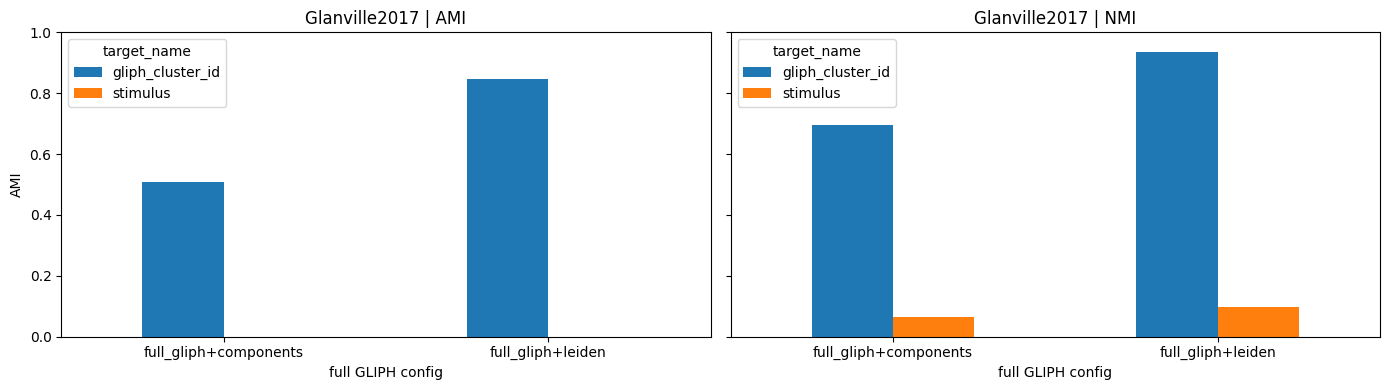

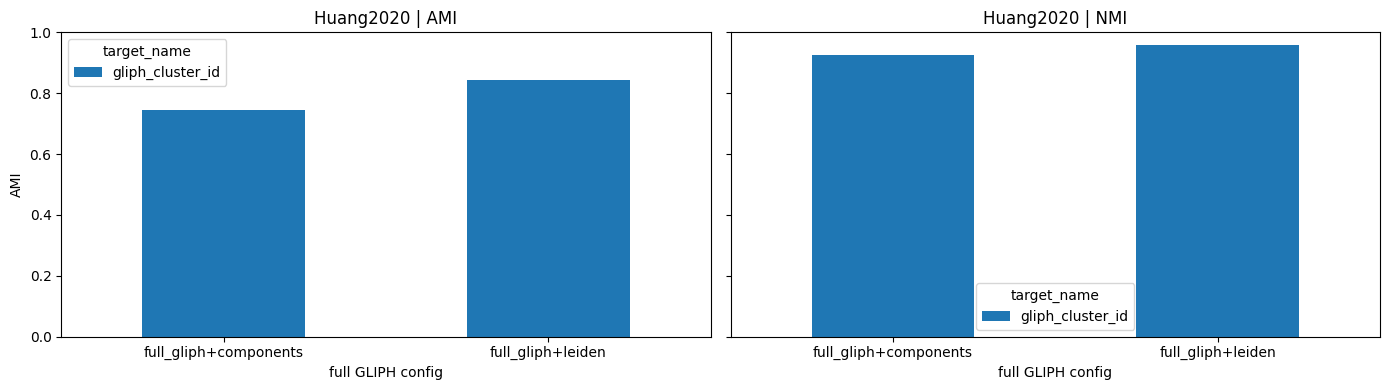

## End-of-Notebook Summary

- GLIPH input was deduplicated to unique `(reference_id, v_gene, junction_aa)` clonotypes before token counting.
- Token extraction uses `clonotype` counts, `8` threads, and unnormalized control background `CONTROL_BACKGROUND_N=1,000,000`.
- Control token families are computed once and reused across both studies.
- Separate binomial tests were run for `v3`, `pos3`, `u3`, `u4`, `g4`, and `g5` with pseudocount smoothing.
- Concordance for `gliph_cluster_id` is evaluated only for target clusters with >=3 clonotypes.
- Concordance targets: Glanville2017 -> `gliph_cluster_id`, `stimulus`, `epitope`; Huang2020 -> `gliph_cluster_id`.
- Glanville2017 enriched token counts: v3=253, pos3=18, u3=5, u4=0, g4=7, g5=0.
- Huang2020 enriched token counts: v3=395, pos3=206, u3=122, u4=47, g4=426, g5=246.
- Glanville2017 vs gliph_cluster_id: best `full_gliph+leiden` with AMI=0.847, NMI=0.935, ARI=0.733, purity=0.825, coverage=15.4%.
- Glanville2017 vs stimulus: best `full_gliph+leiden` with AMI=-0.000, NMI=0.097, ARI=0.000, purity=0.541, coverage=6.8%.
- Glanville2017 vs epitope: no non-empty labels in this dataset snapshot.
- Huang2020 vs gliph_cluster_id: best `full_gliph+leiden` with AMI=0.842, NMI=0.958, ARI=0.739, purity=0.884, coverage=47.3%.

In [19]:
# Diagnostics and compact run summary
for key in sorted(cluster_tables.keys()):
    study, method = key
    tab = cluster_tables[key]
    print(f'\n=== full GLIPH graph + {method} | {study} ===')
    if tab.empty:
        print('  (no clusters)')
    else:
        display(tab.head(10))

focus_studies = {'Glanville2017', 'Huang2020'}
focus_conc = concordance_df[concordance_df['canonical_study'].isin(focus_studies)].copy()
display(focus_conc)

availability_rows = []
for study_name in sorted(focus_studies):
    sdf = df_dedup[df_dedup['reference_id'].str.contains(STUDY_KEYWORDS[study_name], case=False, na=False)].copy()
    if sdf.empty:
        continue
    availability_rows.append({
        'study': study_name,
        'n_rows': len(sdf),
        'n_with_gliph_cluster_id': int((sdf['gliph_cluster_id'].fillna('').astype(str).str.strip() != '').sum()),
        'n_with_stimulus': int((sdf['stimulus'].fillna('').astype(str).str.strip() != '').sum()),
        'n_with_epitope': int((sdf['epitope'].fillna('').astype(str).str.strip() != '').sum()),
    })
availability_df = pd.DataFrame(availability_rows)
print('Target-label availability:')
display(availability_df)

config_order = [f'full_gliph+{method}' for method in CLUSTER_METHODS]
for study_name in sorted(focus_conc['canonical_study'].dropna().unique()):
    study_df_plot = focus_conc[focus_conc['canonical_study'] == study_name].copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    for ax, metric in zip(axes, ['ami', 'nmi']):
        piv = study_df_plot.pivot_table(
            index='config', columns='target_name', values=metric, aggfunc='mean'
        ).reindex(config_order)
        piv.plot(kind='bar', ax=ax)
        ax.set_title(f'{study_name} | {metric.upper()}')
        ax.set_xlabel('full GLIPH config')
        ax.set_ylabel(metric.upper())
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()

requested_targets = {
    'Glanville2017': ['gliph_cluster_id', 'stimulus', 'epitope'],
    'Huang2020': ['gliph_cluster_id'],
}
best_rows = []
for study_name, targets in requested_targets.items():
    for target_name in targets:
        sub_all = focus_conc[
            (focus_conc['canonical_study'] == study_name)
            & (focus_conc['target_name'] == target_name)
        ].copy()
        if sub_all.empty:
            best_rows.append(f'- {study_name} vs {target_name}: no rows available in concordance table.')
            continue
        if int(sub_all['n_target_total'].max()) == 0:
            best_rows.append(f'- {study_name} vs {target_name}: no non-empty labels in this dataset snapshot.')
            continue
        sub = sub_all.dropna(subset=['ami']).copy()
        if sub.empty:
            best_rows.append(
                f"- {study_name} vs {target_name}: labels exist but no evaluable configuration (needs >=2 predicted communities and >=2 target classes)."
            )
            continue
        row = sub.sort_values(['ami', 'n_eval'], ascending=[False, False]).iloc[0]
        best_rows.append(
            f"- {study_name} vs {target_name}: best `{row['config']}` with AMI={row['ami']:.3f}, NMI={row['nmi']:.3f}, ARI={row['ari']:.3f}, purity={row['purity']:.3f}, coverage={row['coverage']:.1%}."
        )

family_count_lines = []
for study in sorted(combined_graph_payloads):
    counts = {family: len(study_results[family][study]['enriched_tokens']) for family in FAMILIES}
    formatted = ', '.join(f"{family}={counts[family]}" for family in FAMILIES)
    family_count_lines.append(f'- {study} enriched token counts: {formatted}.')

summary_lines = [
    '## End-of-Notebook Summary',
    '',
    '- GLIPH input was deduplicated to unique `(reference_id, v_gene, junction_aa)` clonotypes before token counting.',
    f'- Token extraction uses `{COUNT_MODE}` counts, `{TOKEN_THREADS}` threads, and unnormalized control background `CONTROL_BACKGROUND_N={CONTROL_BACKGROUND_N:,}`.',
    '- Control token families are computed once and reused across both studies.',
    '- Separate binomial tests were run for `v3`, `pos3`, `u3`, `u4`, `g4`, and `g5` with pseudocount smoothing.',
    '- Concordance for `gliph_cluster_id` is evaluated only for target clusters with >=3 clonotypes.',
    '- Concordance targets: Glanville2017 -> `gliph_cluster_id`, `stimulus`, `epitope`; Huang2020 -> `gliph_cluster_id`.',
]
summary_lines.extend(family_count_lines)
summary_lines.extend(best_rows)
display(Markdown('\n'.join(summary_lines)))

## Brief Conclusions and Context

- This pipeline reproduces a core GLIPH-like idea: motif/token enrichment against controls, followed by motif-linked clustering.
- Compared to **Huang et al., 2020 (Nat Biotech)** (https://www.nature.com/articles/s41587-020-0505-4), this notebook is a lighter implementation and does not include all GLIPH2 constraints (e.g., global/local motif scoring calibration and full HLA-aware priors).
- Relative to **Glanville et al., 2017 (Nature)** (https://pubmed.ncbi.nlm.nih.gov/28636589/), the bipartite token graph here captures motif-sharing structure similarly, but exact cluster boundaries may differ because we use explicit binomial enrichment + FDR thresholds and connected-component/community heuristics.
- Practical interpretation:
  - Higher Cramer's V / AMI / NMI and lower stimulated-unclustered fraction indicate better stimulus separation by token-defined clusters.
  - Silhouette can be conservative in sparse high-dimensional token spaces; use it together with chi2/Cramer's V and cluster composition tables.

A run-specific summary is generated in the final code cell as **End-of-Notebook Summary** after all computations complete.

In [20]:
# Repeat final summary at literal notebook end for convenience.
if 'summary_lines' in globals():
    display(Markdown('\n'.join(summary_lines)))
else:
    print('Run the previous analysis cell first to generate end-of-notebook summary.')

## End-of-Notebook Summary

- GLIPH input was deduplicated to unique `(reference_id, v_gene, junction_aa)` clonotypes before token counting.
- Token extraction uses `clonotype` counts, `8` threads, and unnormalized control background `CONTROL_BACKGROUND_N=1,000,000`.
- Control token families are computed once and reused across both studies.
- Separate binomial tests were run for `v3`, `pos3`, `u3`, `u4`, `g4`, and `g5` with pseudocount smoothing.
- Concordance for `gliph_cluster_id` is evaluated only for target clusters with >=3 clonotypes.
- Concordance targets: Glanville2017 -> `gliph_cluster_id`, `stimulus`, `epitope`; Huang2020 -> `gliph_cluster_id`.
- Glanville2017 enriched token counts: v3=253, pos3=18, u3=5, u4=0, g4=7, g5=0.
- Huang2020 enriched token counts: v3=395, pos3=206, u3=122, u4=47, g4=426, g5=246.
- Glanville2017 vs gliph_cluster_id: best `full_gliph+leiden` with AMI=0.847, NMI=0.935, ARI=0.733, purity=0.825, coverage=15.4%.
- Glanville2017 vs stimulus: best `full_gliph+leiden` with AMI=-0.000, NMI=0.097, ARI=0.000, purity=0.541, coverage=6.8%.
- Glanville2017 vs epitope: no non-empty labels in this dataset snapshot.
- Huang2020 vs gliph_cluster_id: best `full_gliph+leiden` with AMI=0.842, NMI=0.958, ARI=0.739, purity=0.884, coverage=47.3%.

In [21]:
# Diagnostic: why AMI/NMI bars may be blank
diag_rows = []
for study, payload in combined_graph_payloads.items():
    study_df = payload['study_df']
    for method in CLUSTER_METHODS:
        labels_map = cluster_labels[(study, method)]
        for target_col in ['gliph_cluster_id', 'stimulus']:
            tmp = study_df[['row_id', target_col]].copy()
            tmp['target'] = tmp[target_col].fillna('').astype(str).str.strip()
            tmp = tmp[~tmp['target'].str.lower().isin({'', 'nan', 'none', 'na'})].copy()
            tmp['pred'] = tmp['row_id'].map(labels_map).fillna(-1).astype(int)
            eval_df = tmp[tmp['pred'] >= 0].copy()
            diag_rows.append({
                'study': study,
                'method': method,
                'target': target_col,
                'n_target_total': len(tmp),
                'n_eval': len(eval_df),
                'pred_nunique': int(eval_df['pred'].nunique()) if len(eval_df) else 0,
                'target_nunique': int(eval_df['target'].nunique()) if len(eval_df) else 0,
            })

diag_df = pd.DataFrame(diag_rows)
display(diag_df.sort_values(['study', 'method', 'target']))

,study,method,target,n_target_total,n_eval,pred_nunique,target_nunique
0,Glanville2017,components,gliph_cluster_id,1287,113,11,83
1,Glanville2017,components,stimulus,3930,266,15,5
2,Glanville2017,leiden,gliph_cluster_id,1287,113,26,83
3,Glanville2017,leiden,stimulus,3930,266,30,5
4,Huang2020,components,gliph_cluster_id,4493,1449,421,773
5,Huang2020,components,stimulus,9934,1831,470,1
6,Huang2020,leiden,gliph_cluster_id,4493,1449,433,773
7,Huang2020,leiden,stimulus,9934,1831,482,1
